# 02 · Descriptive Analysis

Summary statistics and descriptive visualisations for the dataset.

**Prerequisite:** Run  first.


In [1]:
import sys
sys.path.append("../functions")

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd

from config import RESULTS_DIR, FIGURES_DIR, HOUSING_TYPE_COLOURS, HOUSING_ORDER, INNER_LONDON_BOROUGHS
from data_loader import load_london_lad

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Load prepared data

In [2]:
comment_df    = pd.read_parquet(RESULTS_DIR / "comments.parquet")
application_df = pd.read_parquet(RESULTS_DIR / "applications.parquet")
london_lad     = load_london_lad()

print(f"Comments:     {len(comment_df):,}")
print(f"Applications: {len(application_df):,}")


Comments:     30,393
Applications: 5,235


## Summary statistics

In [3]:
overall = {
    "total_applications":                  application_df["lpa_app_no"].nunique(),
    "total_proposed_residential_units":    application_df["total_no_proposed_residential_units"].sum(),
    "total_comments":                      application_df["comment_count"].sum(),
    "mean_comments_per_application":       application_df["comment_count"].mean().round(2),
}
pd.Series(overall).rename("value")


total_applications                   5071.00
total_proposed_residential_units    66485.00
total_comments                      30399.00
mean_comments_per_application           5.81
Name: value, dtype: float64

In [4]:
# Per-council stats
council_stats = (
    application_df
    .groupby("borough")
    .agg(
        total_applications=("lpa_app_no", "count"),
        total_proposed_units=("total_no_proposed_residential_units", "sum"),
        total_comments=("comment_count", "sum"),
        mean_comments=("comment_count", "mean"),
    )
    .reset_index()
)
council_stats


,borough,total_applications,total_proposed_units,total_comments,mean_comments
0,Barnet,1308,10128,9262,7.081040
1,Brent,935,12509,2291,2.450267
2,City of London,21,3899,38,1.809524
3,Ealing,1123,12182,11314,10.074800
4,Lambeth,546,3347,2834,5.190476
5,Newham,497,11264,922,1.855131
6,Southwark,308,7054,2396,7.779221
7,Westminster,497,6102,1342,2.700201


## Map of included local authorities

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_93141/1857453703.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  highlighted["centroid"]   = highlighted.geometry.centroid


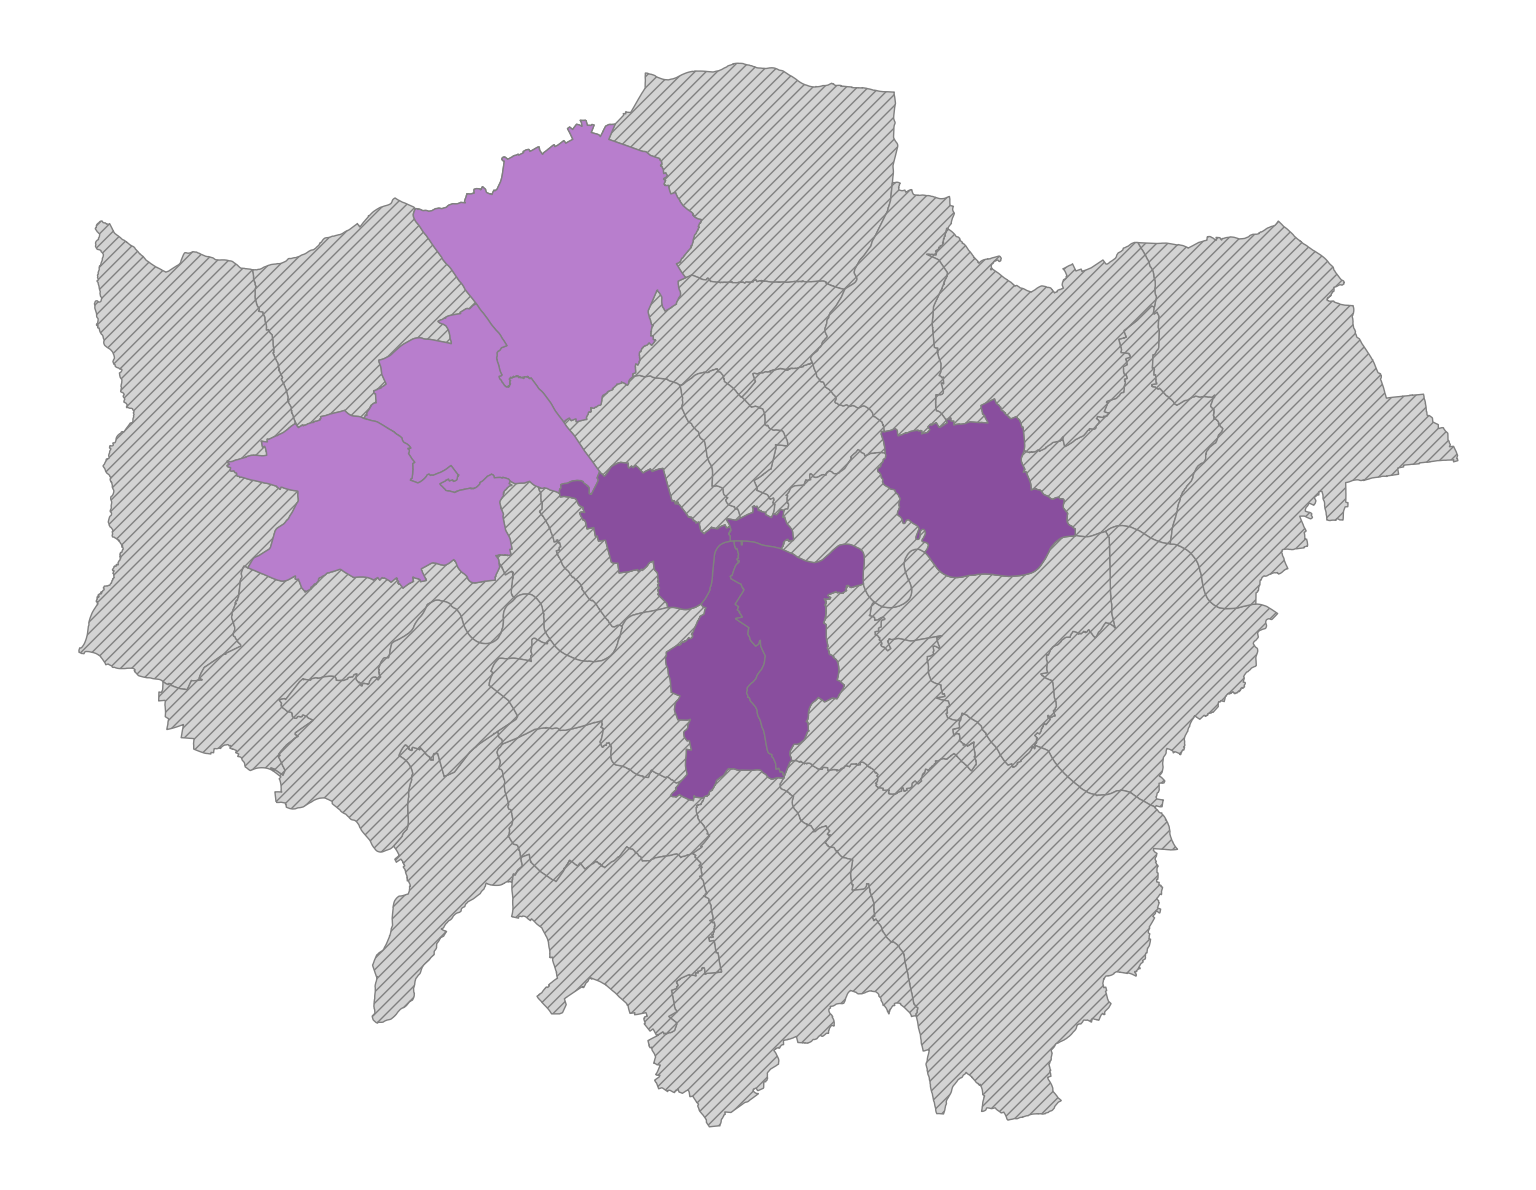

In [5]:
included_lads = list(application_df["borough"].unique())

def assign_side(row, minx, maxx, miny, maxy):
    x, y = row["centroid_x"], row["centroid_y"]
    distances = {"left": abs(x - minx), "right": abs(maxx - x),
                 "top": abs(maxy - y), "bottom": abs(y - miny)}
    return min(distances, key=distances.get)

minx, miny, maxx, maxy = london_lad.total_bounds
highlighted = london_lad[london_lad["LAD24NM"].isin(included_lads)].copy()
highlighted["centroid"]   = highlighted.geometry.centroid
highlighted["centroid_x"] = highlighted["centroid"].apply(lambda p: p.x)
highlighted["centroid_y"] = highlighted["centroid"].apply(lambda p: p.y)
highlighted["side"]       = highlighted.apply(assign_side, axis=1,
                                               minx=minx, maxx=maxx, miny=miny, maxy=maxy)

london_lad["highlight"] = london_lad["LAD24NM"].isin(included_lads)
cmap = {"Inner London": "#894e9e", "Outer London": "#b87ecd"}
london_lad["colour"] = london_lad["london_area"].map(cmap)

fig, ax = plt.subplots(figsize=(16, 12))
london_lad.plot(ax=ax, color="lightgrey", edgecolor="grey", hatch="///")
london_lad[london_lad["highlight"]].plot(ax=ax, color=london_lad[london_lad["highlight"]]["colour"], edgecolor="grey")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "london_lad_map.png", dpi=150, bbox_inches="tight")
plt.show()


## Comment-count distributions

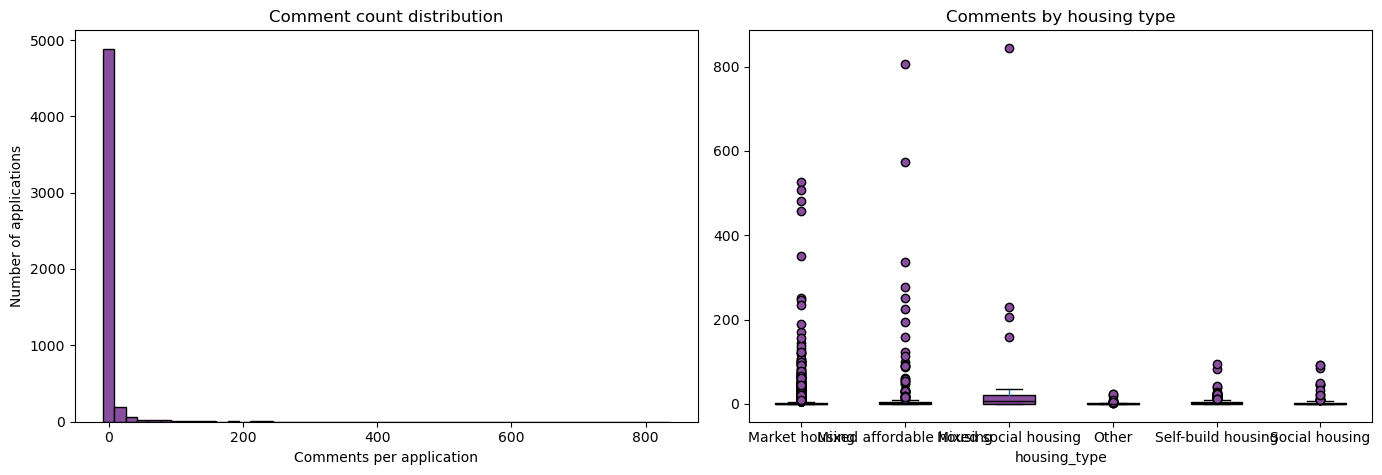

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(application_df["comment_count"], bins=50, color="#894e9e",
             edgecolor="black", align="left")
axes[0].set_xlabel("Comments per application")
axes[0].set_ylabel("Number of applications")
axes[0].set_title("Comment count distribution")

# Box plot by housing type
application_df.boxplot(
    column="comment_count", by="housing_type",
    ax=axes[1], grid=False, patch_artist=True,
    boxprops=dict(facecolor="#894e9e", color="black"),
    medianprops=dict(color="black"),
    flierprops=dict(markerfacecolor="#894e9e", markeredgecolor="black"),
)
axes[1].set_title("Comments by housing type")
plt.suptitle("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comment_count_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## Units vs comments scatter (by housing type)

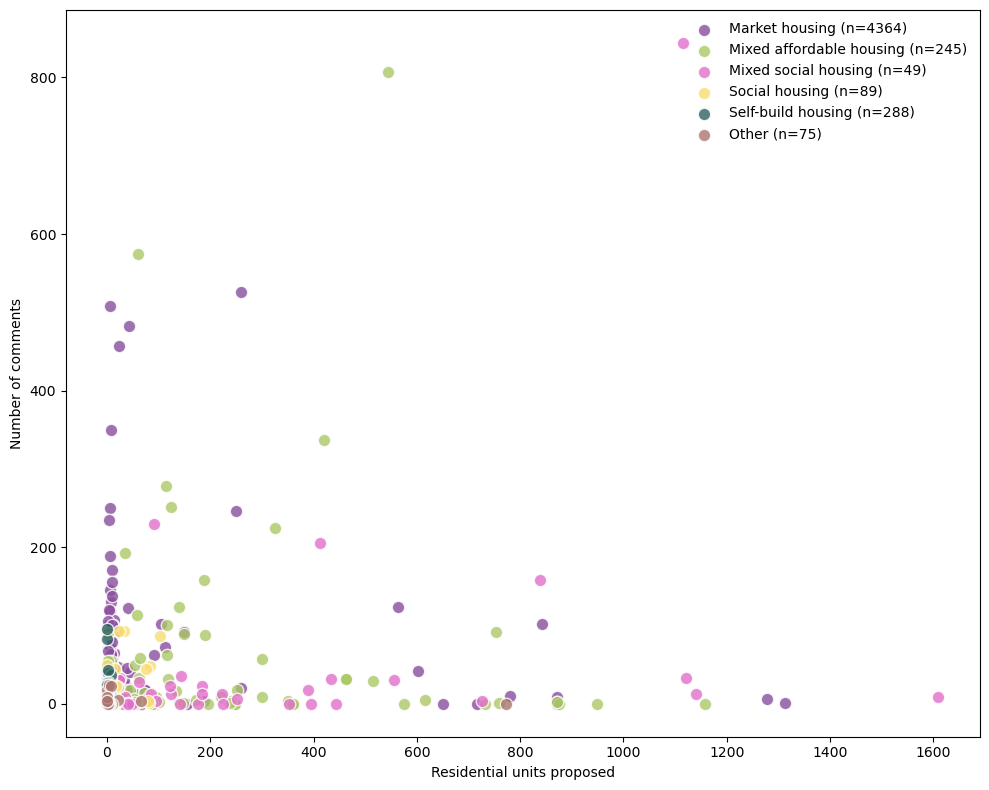

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
for ht in HOUSING_ORDER:
    sub = application_df[application_df["housing_type"] == ht]
    if sub.empty:
        continue
    ax.scatter(
        sub["total_no_proposed_residential_units"],
        sub["comment_count"],
        color=HOUSING_TYPE_COLOURS.get(ht, "grey"),
        label=f"{ht} (n={len(sub)})",
        alpha=0.8, edgecolors="w", s=80,
    )
ax.set_xlabel("Residential units proposed")
ax.set_ylabel("Number of comments")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "units_vs_comments_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
